In [1]:
import pandas as pd
import numpy as np
import os
import re

In [6]:
import chardet

# 检测文件编码
with open("C:/Users/WQM/Desktop/本科毕业论文/数据集/FNSPID/output.csv", 'rb') as f:
    result = chardet.detect(f.read(1000000))  # 检测前10000个字节
    print(result['encoding'])

Windows-1252


In [ ]:
with open("C:/Users/WQM/Desktop/本科毕业论文/数据集/FNSPID/output.csv", encoding='utf-8', errors='ignore') as f:
    data = pd.read_csv(f)

In [28]:
pd.set_option('display.max_colwidth', None)  # 取消列内容的截断

In [12]:
data2= data.loc[:, ['Date', 'Stock_symbol', 'Article_title', 'Article', 'Url', 'Publisher']]

In [13]:
data2.drop_duplicates(subset=['Url'], inplace= True)

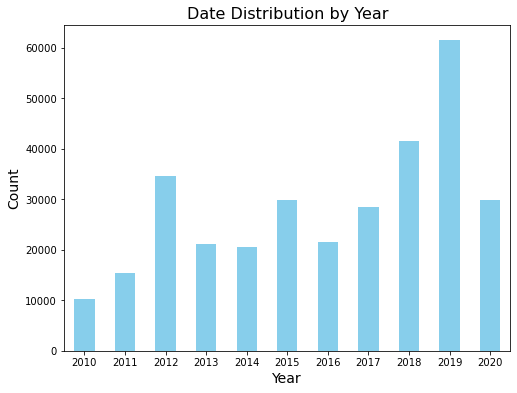

In [14]:
import matplotlib.pyplot as plt

data2['Year'] = pd.to_datetime(data2['Date']).dt.year

# 计算每年出现的日期数量
yearly_counts = data2['Year'].value_counts().sort_index()

# 绘制柱状图
plt.figure(figsize=(8, 6))
yearly_counts.plot(kind='bar', color='skyblue')

# 添加标题和标签
plt.title('Date Distribution by Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Count', fontsize=14)

# 显示图表
plt.xticks(rotation=0)
plt.show()

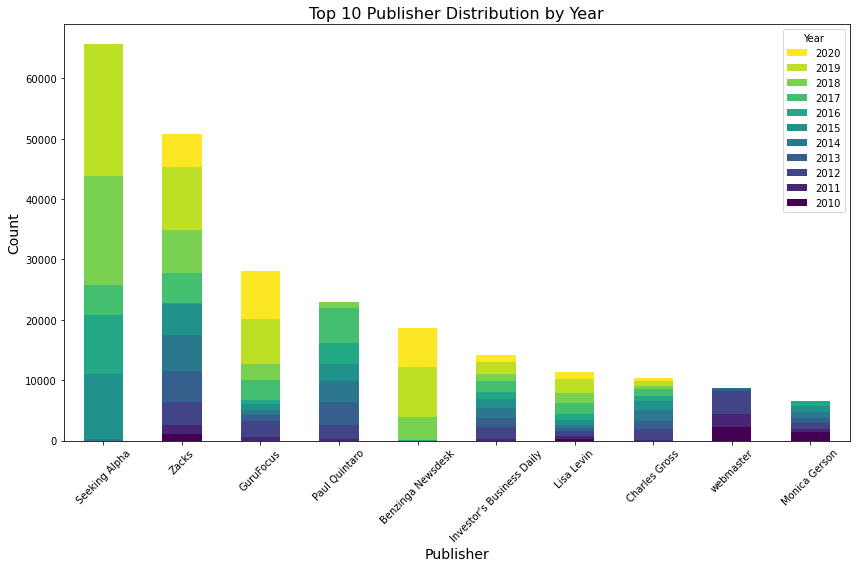

In [15]:
# 计算每个Publisher在每一年出现的次数
publisher_year_counts = data2.groupby(['Publisher', 'Year']).size().unstack(fill_value=0)

# 只保留出现次数最多的前10个Publisher
top_publishers = data2['Publisher'].value_counts().head(10).index
publisher_year_counts = publisher_year_counts.loc[top_publishers]

# 获取年份列表
years = publisher_year_counts.columns

# 为不同年份创建渐变色
colors = plt.cm.viridis(np.linspace(0, 1, len(years)))

# 绘制堆叠柱状图
ax = publisher_year_counts.plot(kind='bar', stacked=True, figsize=(12, 8), color=colors)

# 添加标题和标签
plt.title('Top 10 Publisher Distribution by Year', fontsize=16)
plt.xlabel('Publisher', fontsize=14)
plt.ylabel('Count', fontsize=14)

# 调整图例顺序
handles, labels = ax.get_legend_handles_labels()
# 创建一个字典，将年份与图例句柄映射在一起
legend_dict = dict(zip(labels, handles))
# 按年份降序排序字典
sorted_labels = sorted(legend_dict.keys(), reverse=True)
sorted_handles = [legend_dict[label] for label in sorted_labels]
# 设置图例
plt.legend(sorted_handles, sorted_labels, title='Year')

# 显示图表
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
data2.to_csv("2010-2020股票新闻（完整版）.csv", index= False)

In [45]:
data3 = pd.DataFrame()

In [46]:
for year in range(2010, 2021):
    # 按年份过滤数据
    df_year = data2[data2['Year'] == year]
    
    # 如果该年的数据量大于10000，则随机抽样10000条，否则取该年的所有数据
    if len(df_year) > 10000:
        df_sample = df_year.sample(n=10000, random_state=12)
    else:
        df_sample = df_year
    
    # 将每年的样本数据追加到新的DataFrame
    data3 = pd.concat([data3, df_sample])

In [47]:
# 整理dataframe顺序
data3 = data3.sort_values(by=['Date', 'Stock_symbol'], ascending=[True, True])
data3.reset_index(drop= True, inplace= True)

In [50]:
data3.to_csv("2010-2020股票新闻.csv", index= False)

In [1]:
# website fetch

In [2]:
import pandas as pd
import requests
import time
import random
import re
import os
import warnings

In [3]:
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed

In [4]:
# 禁用所有警告
warnings.filterwarnings("ignore")

In [5]:
data= pd.read_csv("C:/Users/WQM/Desktop/本科毕业论文/数据集/FNSPID/2010-2020股票新闻（简略版2）.csv", dtype= str)
data= pd.DataFrame(data)

In [6]:
# 提取文章的函数
def fetch_article(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')
        
        article_div = soup.find('div', class_='article-content-body-only')
        if article_div:
            article = article_div.get_text(separator=' ', strip=True)
            return article
        else:
            return None
    except:
        return None

In [7]:
# 分批处理并保存结果的函数
def process_batch(batch_df, batch_num, output_file):
    results = {}
    
    with ThreadPoolExecutor(max_workers=50) as executor:
        futures = {executor.submit(fetch_article, url): index for index, url in zip(batch_df.index, batch_df['Url'])}
        
        for future in as_completed(futures):
            index = futures[future]
            article = future.result()
            results[index] = article
    
    # 将结果加入 DataFrame
    for index, article in results.items():
        batch_df.at[index, 'Article'] = article
    
    # 计算成功提取的数量
    success_count = batch_df['Article'].notna().sum()
    
    # 检查成功提取数量
    if success_count == 0:
        print(f'No articles extracted in batch {batch_num + 1}. Stopping further processing.')
        return False  # 返回 False 表示不继续处理
    
    # 保存有效的 URL
    valid_urls_df = batch_df[batch_df['Article'].notna()]
    valid_urls_df.to_csv(output_file, mode='a', index=False, header=not os.path.exists(output_file))
    
    print(f'Batch {batch_num + 1} processed: {success_count}/{len(batch_df)} articles successfully extracted.')
    return True  # 返回 True 表示继续处理

In [8]:
# 主函数，按批次处理所有数据
def process_in_batches(df, start_row, batch_size, output_file):
    total_rows = len(df)

    while start_row < total_rows:
        end_row = min(start_row + batch_size, total_rows)
        print(f"Processing rows {start_row} to {end_row}")
        
        batch_df = df.iloc[start_row:end_row]
        
        if not process_batch(batch_df, start_row // batch_size, output_file):
            break  # 如果返回 False，则中断循环
        
        start_row += batch_size

In [ ]:
# 调用分组处理函数
batch_size= 1000
start_row= 139000

input_file= data
output_file='output3.csv'

process_in_batches(input_file, start_row, batch_size, output_file)

In [45]:
data= pd.read_csv("C:/Users/WQM/Desktop/本科毕业论文/数据集/FNSPID/2010-2020股票新闻（完整版）.csv", dtype= str)
data= pd.DataFrame(data)

In [46]:
data2= pd.read_csv("C:/Users/WQM/Desktop/本科毕业论文/数据集/FNSPID/2010-2020股票新闻（简略版）.csv", dtype= str)
data2= pd.DataFrame(data2)

In [47]:
# 过滤掉 data 中 Url 列存在于 data2 中的行
data3 = data[~data['Url'].isin(data2['Url'])]

In [48]:
data3.to_csv('2010-2020股票新闻（简略版2）.csv', index= False)

In [18]:
# Test

In [19]:
# 提取文章的函数
def fetch_article(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')
        
        article_div = soup.find('div', class_='article-content-body-only')
        if article_div:
            article = article_div.get_text(separator=' ', strip=True)
            return article
        else:
            return None
    except:
        return None

In [ ]:
url= 'https://www.benzinga.com/content/zacks-investment-research-all-commentary-articles/11/06/1204493/bsd-medical-makes-classic-pa'
fetch_article(url)

In [ ]:
'''
# 遍历每个URL
for index, row in data3.head(5).iterrows():
    print(f"Fetching article from: {row['Url']}")
    article = fetch_article(row['Url'])
    
    if article:
        data3.at[index, 'Article'] = article
    
    # 随机延迟，避免请求过快
    time.sleep(random.uniform(1, 3))  # 在1到3秒之间随机延迟
'''